<a href="https://colab.research.google.com/github/DiorgenesSilva/Tecnologia-em-Ciencia-de-dados/blob/main/C%C3%B3pia_de_analise_classic_metal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()
#Aplique essse codigo p baixar a base de dados

Saving analise_classic_metal_1.ipynb to analise_classic_metal_1 (1).ipynb
Saving ClassicMetal.csv to ClassicMetal.csv


# 🎸 Análise de Dados: Classic Metal (Spotify Audio Features)

**Dataset:** `ClassicMetal.csv` — 922 faixas, 100 artistas, atributos de áudio extraídos do Spotify (Danceability, Energy, Loudness, Tempo, Popularity, etc.) cobrindo lançamentos de 1968 a 2022.

**Objetivo do projeto**

Este notebook é um projeto de Ciência de Dados do nível básico→intermediário, estruturado como um pipeline completo:

1. Carregamento e entendimento dos dados
2. Limpeza e qualidade dos dados
3. Engenharia de atributos
4. Análise exploratória (univariada e bivariada)
5. Evolução temporal do gênero
6. **Diferenciais:**
   - 🔹 Clusterização (K-Means) para encontrar "perfis sonoros" dentro do Classic Metal
   - 🔹 Redução de dimensionalidade (PCA) para visualizar os clusters
   - 🔹 Teste estatístico (ANOVA) para validar se a Energia mudou entre décadas
   - 🔹 Modelo preditivo (Random Forest) para estimar a Popularidade de uma faixa
   - 🔹 Importância de variáveis (feature importance)

> **Como usar:** mantenha o arquivo `ClassicMetal.csv` na mesma pasta deste notebook e execute as células em ordem (Run All).


In [ ]:
# Bibliotecas principais
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configurações visuais
sns.set_theme(style="whitegrid", palette="rocket")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


## 1. Carregamento e Visão Geral dos Dados

In [ ]:
df = pd.read_csv('ClassicMetal.csv')

print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Dimensões: 922 linhas x 18 colunas


,Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
0,3 Libras,A Perfect Circle,Mer De Noms,2000,219640,3,0.518,0.744,9,-8.248,1,0.037,0.004,0.007,0.078,0.211,144.019,58
1,By And Down The River,A Perfect Circle,Eat The Elephant,2003,304906,3,0.231,0.640,9,-5.454,0,0.036,0.001,0.104,0.119,0.050,97.503,45
2,Counting Bodies Like Sheep To The Rhythm Of Th...,A Perfect Circle,eMOTIVe,2004,336440,4,0.632,0.938,8,-6.999,1,0.339,0.047,0.006,0.098,0.227,135.787,49
3,Imagine,A Perfect Circle,eMOTIVe,2004,288000,4,0.537,0.495,8,-6.188,1,0.025,0.127,0.005,0.109,0.155,73.019,46
4,Judith,A Perfect Circle,Mer De Noms,2000,247266,3,0.366,0.894,11,-4.682,0,0.057,0.000,0.170,0.267,0.304,82.305,65


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 922 entries, 0 to 921
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             922 non-null    object 
 1   Artist            922 non-null    object 
 2   Album             920 non-null    object 
 3   Year              922 non-null    int64  
 4   Duration          922 non-null    int64  
 5   Time_Signature    922 non-null    int64  
 6   Danceability      922 non-null    float64
 7   Energy            922 non-null    float64
 8   Key               922 non-null    int64  
 9   Loudness          922 non-null    float64
 10  Mode              922 non-null    int64  
 11  Speechiness       922 non-null    float64
 12  Acousticness      922 non-null    float64
 13  Instrumentalness  922 non-null    float64
 14  Liveness          922 non-null    float64
 15  Valence           922 non-null    float64
 16  Tempo             922 non-null    float64
 1

## 2. Dicionário de Dados

| Coluna | Descrição |
|---|---|
| `Track` | Nome da faixa |
| `Artist` | Artista/banda |
| `Album` | Álbum de origem |
| `Year` | Ano de lançamento |
| `Duration` | Duração da faixa em milissegundos |
| `Time_Signature` | Fórmula de compasso estimada |
| `Danceability` | 0–1, quão dançável é a faixa |
| `Energy` | 0–1, intensidade e atividade percebida |
| `Key` | Tom musical (notação numérica, 0=C, 1=C♯/D♭, ...) |
| `Loudness` | Volume médio em decibéis (dB), tipicamente negativo |
| `Mode` | 1 = tom maior, 0 = tom menor |
| `Speechiness` | 0–1, presença de conteúdo falado |
| `Acousticness` | 0–1, confiança de que a faixa é acústica |
| `Instrumentalness` | 0–1, ausência de vocais |
| `Liveness` | 0–1, probabilidade de ter sido gravada com audiência presente |
| `Valence` | 0–1, "positividade" musical transmitida |
| `Tempo` | Andamento estimado em BPM |
| `Popularity` | 0–100, popularidade da faixa no Spotify |


## 3. Qualidade dos Dados

Antes de qualquer análise, verificamos valores nulos, duplicados e tipos inconsistentes.

In [ ]:
# Valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nLinhas com Album nulo:")
display(df[df['Album'].isnull()])


Valores nulos por coluna:
Album    2
dtype: int64

Linhas com Album nulo:


,Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
210,Over the Mountain,Ozzy Osbourne,NaN,1981,271000,4,0.493,0.866,0,-5.665,1,0.098,0.002,0.000,0.077,0.489,131.060,53
621,Empire,Queensryche,NaN,1990,347000,4,0.467,0.628,7,-5.645,1,0.027,0.058,0.000,0.120,0.105,140.214,32


In [ ]:
# Duplicados (mesma faixa, artista e álbum)
dup_mask = df.duplicated(subset=['Track', 'Artist', 'Album'], keep=False)
print(f"Linhas envolvidas em duplicidade: {dup_mask.sum()}")
display(df[dup_mask].sort_values(['Artist', 'Track']))


Linhas envolvidas em duplicidade: 4


,Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
393,Painkiller,Judas Priest,Painkiller,1990,365826,4,0.435,0.987,1,-4.667,0,0.160,0.000,0.088,0.268,0.100,103.162,65
394,Painkiller,Judas Priest,Painkiller,1990,365000,4,0.435,0.987,1,-4.667,0,0.160,0.000,0.088,0.268,0.100,103.162,66
397,Turbo Lover - Remastered,Judas Priest,Turbo 30,1986,333999,4,0.551,0.876,9,-7.020,1,0.037,0.174,0.000,0.397,0.746,151.575,54
398,Turbo Lover - Remastered,Judas Priest,Turbo 30,1986,334000,4,0.551,0.876,9,-7.020,1,0.037,0.174,0.000,0.397,0.746,151.575,55


## 4. Limpeza dos Dados

- **Álbum nulo:** preenchemos com `"Desconhecido"` em vez de remover a linha (faixa e demais atributos são válidos).
- **Duplicados:** mantemos apenas a primeira ocorrência de cada combinação `Track + Artist + Album`.
- **Sanity check:** garantimos que não há anos fora de um intervalo plausível e que as features 0–1 realmente estão nesse range.

In [ ]:
df_clean = df.copy()

# Tratar Album nulo
df_clean['Album'] = df_clean['Album'].fillna('Desconhecido')

# Remover duplicados
linhas_antes = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Track', 'Artist', 'Album'], keep='first')
print(f"Linhas removidas por duplicidade: {linhas_antes - len(df_clean)}")

# Sanity check de ranges (features que deveriam estar entre 0 e 1)
features_01 = ['Danceability', 'Energy', 'Speechiness', 'Acousticness',
               'Instrumentalness', 'Liveness', 'Valence']
fora_do_range = df_clean[(df_clean[features_01] < 0).any(axis=1) | (df_clean[features_01] > 1).any(axis=1)]
print(f"Linhas com features 0-1 fora do intervalo: {len(fora_do_range)}")

print(f"\nDataset final: {df_clean.shape[0]} linhas x {df_clean.shape[1]} colunas")


Linhas removidas por duplicidade: 2
Linhas com features 0-1 fora do intervalo: 0

Dataset final: 920 linhas x 18 colunas


## 5. Engenharia de Atributos

Criamos colunas derivadas que vão facilitar a análise e os modelos mais adiante:

- `Duration_min`: duração em minutos (mais legível que milissegundos)
- `Decade`: década de lançamento, para analisar tendências ao longo do tempo
- `Mode_label`: rótulo textual do `Mode` (Maior/Menor)

In [ ]:
df_clean['Duration_min'] = (df_clean['Duration'] / 60000).round(2)
df_clean['Decade'] = (df_clean['Year'] // 10 * 10).astype(int)
df_clean['Mode_label'] = df_clean['Mode'].map({1: 'Maior', 0: 'Menor'})

df_clean[['Track', 'Artist', 'Year', 'Decade', 'Duration_min', 'Mode_label']].head()


,Track,Artist,Year,Decade,Duration_min,Mode_label
0,3 Libras,A Perfect Circle,2000,2000,3.660,Maior
1,By And Down The River,A Perfect Circle,2003,2000,5.080,Menor
2,Counting Bodies Like Sheep To The Rhythm Of Th...,A Perfect Circle,2004,2000,5.610,Maior
3,Imagine,A Perfect Circle,2004,2000,4.800,Maior
4,Judith,A Perfect Circle,2000,2000,4.120,Menor


## 6. Análise Exploratória Univariada

Distribuição das principais variáveis de áudio.

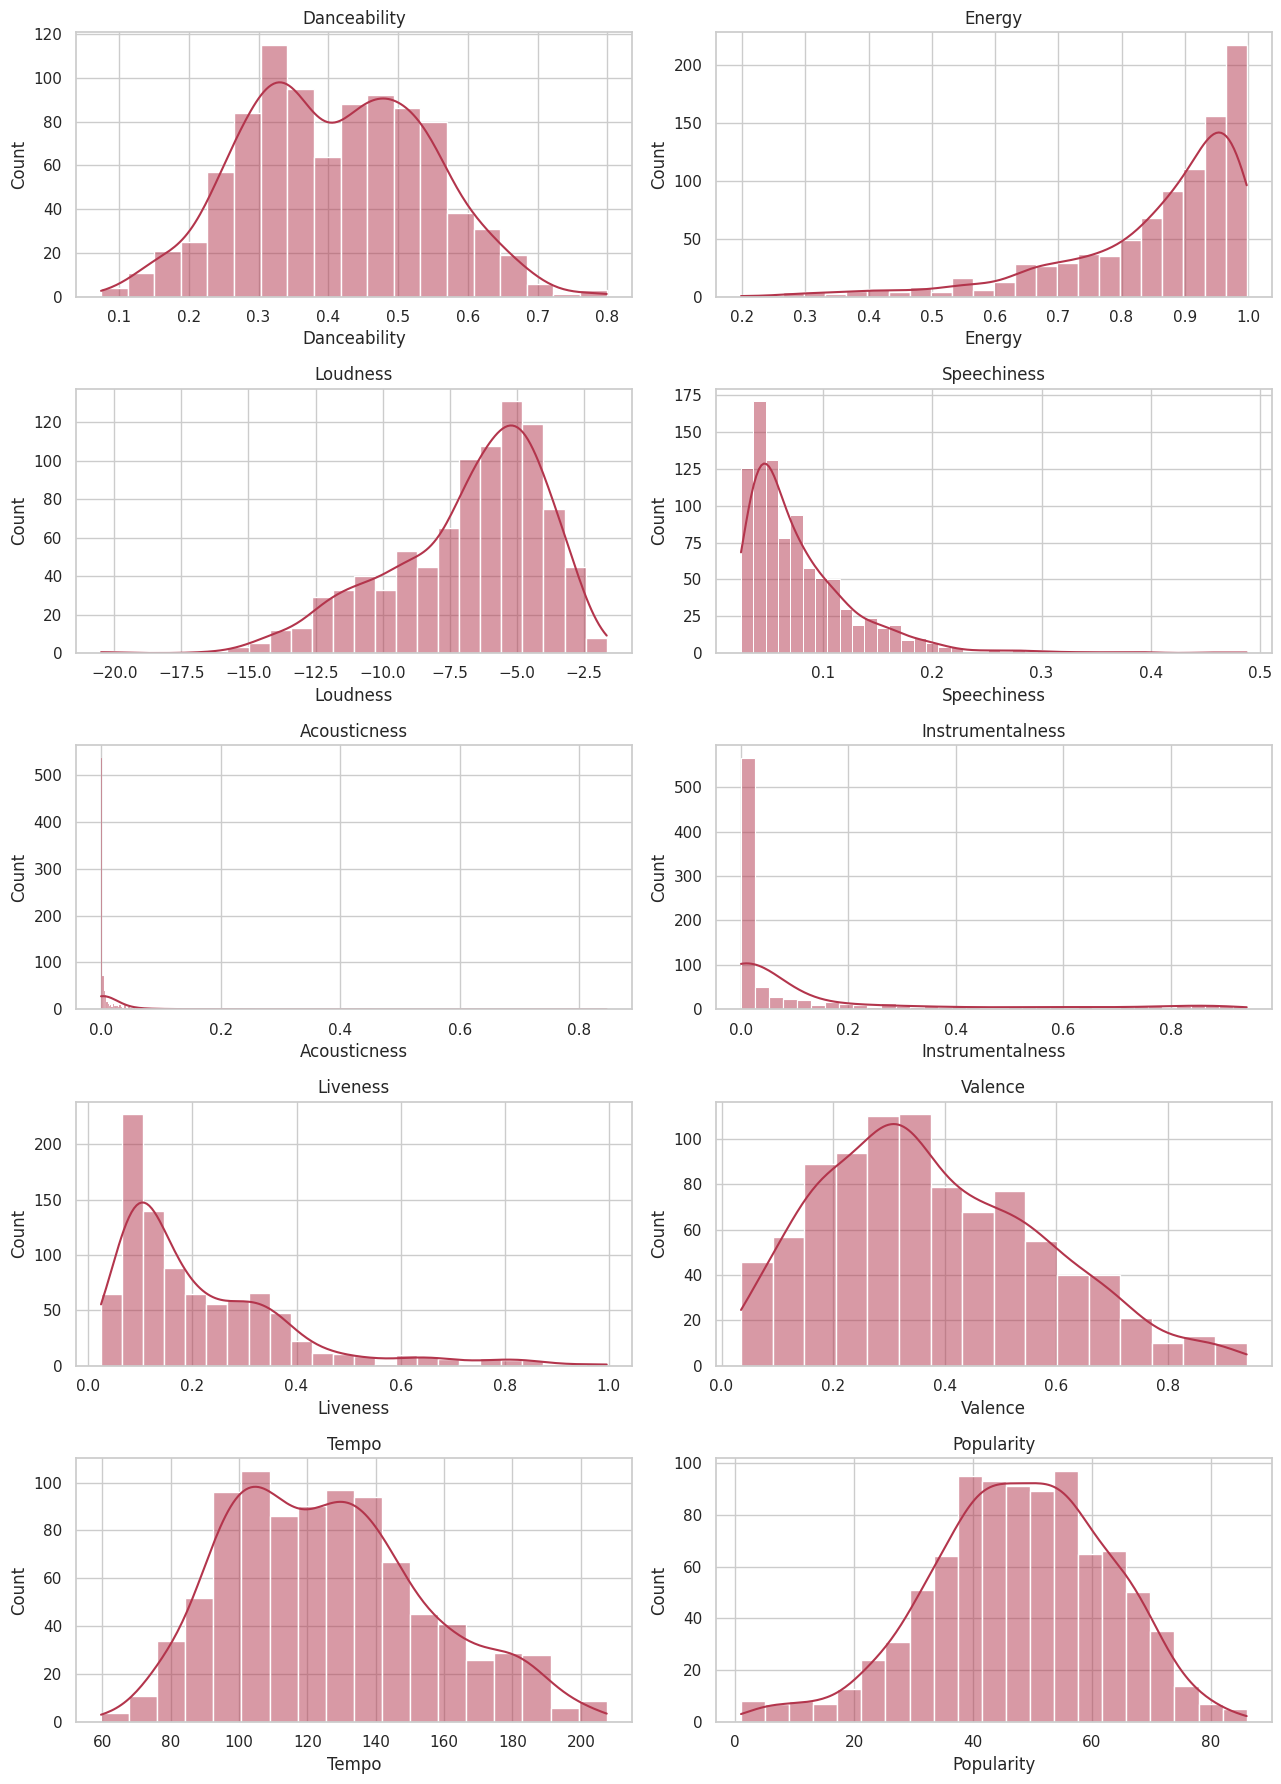

In [ ]:
features_audio = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
                   'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
                   'Tempo', 'Popularity']

fig, axes = plt.subplots(5, 2, figsize=(13, 18))
axes = axes.flatten()

for i, col in enumerate(features_audio):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='#b3354c')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


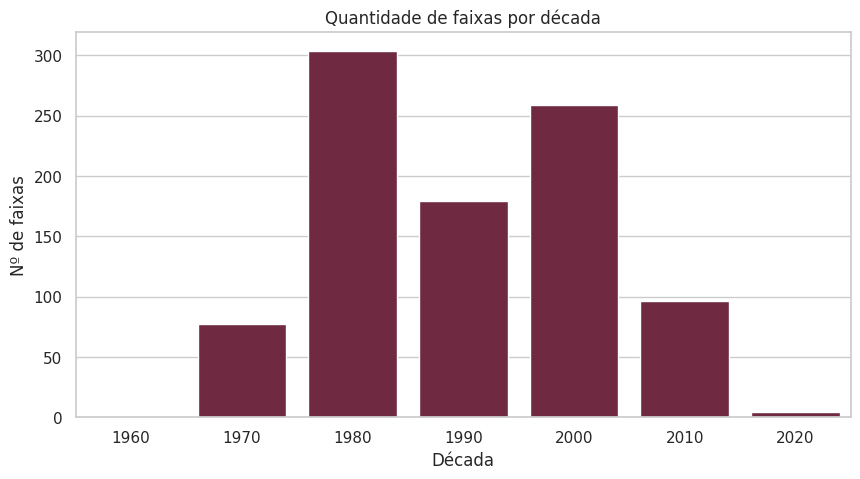

In [ ]:
# Quantidade de faixas por década
plt.figure(figsize=(10, 5))
ordem_decadas = sorted(df_clean['Decade'].unique())
sns.countplot(data=df_clean, x='Decade', order=ordem_decadas, color='#7a1f3d')
plt.title('Quantidade de faixas por década')
plt.xlabel('Década')
plt.ylabel('Nº de faixas')
plt.show()


## 7. Análise Exploratória Bivariada e Correlações

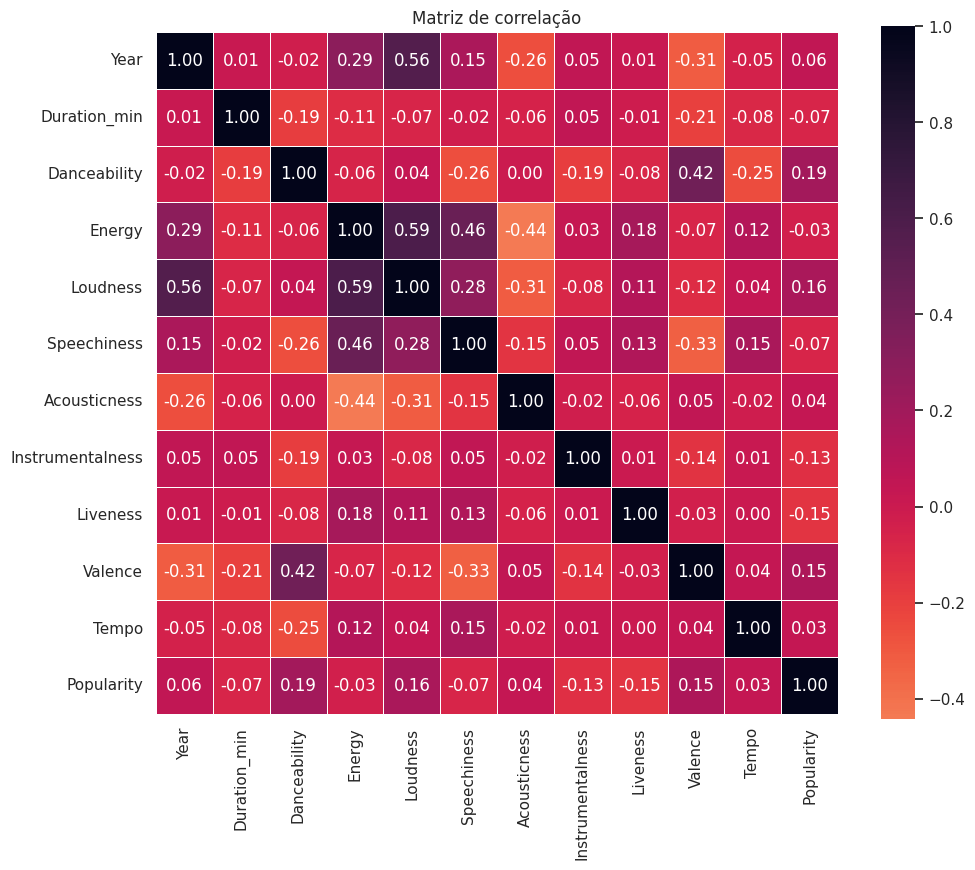

In [ ]:
num_cols = ['Year', 'Duration_min', 'Danceability', 'Energy', 'Loudness',
            'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness',
            'Valence', 'Tempo', 'Popularity']

plt.figure(figsize=(11, 9))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket_r', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de correlação')
plt.show()


**Leitura rápida da matriz:** dentro deste dataset, `Energy` e `Loudness` caminham juntas (faixas mais altas tendem a ser mais energéticas), enquanto `Acousticness` se comporta de forma quase oposta a `Energy` e `Loudness` — coerente com a expectativa: quanto mais "acústica" a faixa, menos ela tende a ser pesada/alta. Já a `Popularity` tem correlações fracas com **todas** as variáveis de áudio (a mais forte é com `Danceability`, ainda assim moderada). Isso é um sinal importante para a etapa de modelagem preditiva mais adiante: não devemos esperar um modelo com altíssima precisão usando só estas variáveis.

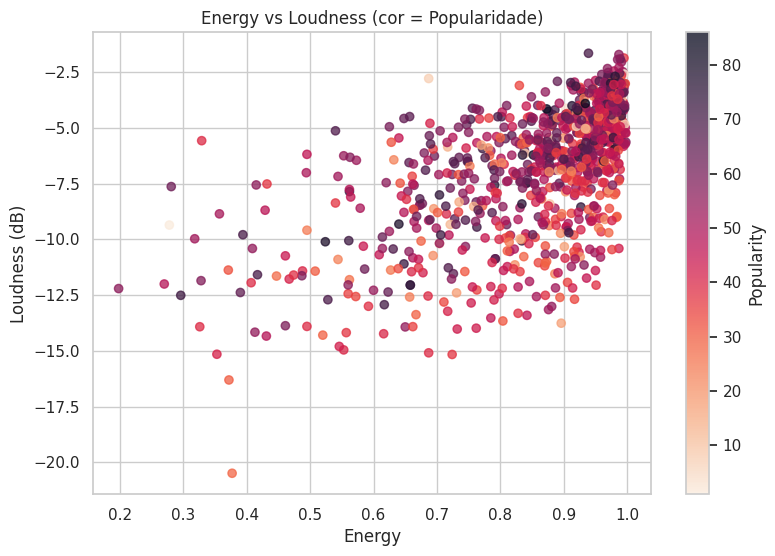

In [ ]:
# Energy x Loudness, colorido por Popularity
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df_clean['Energy'], df_clean['Loudness'],
                       c=df_clean['Popularity'], cmap='rocket_r', alpha=0.75)
plt.colorbar(scatter, label='Popularity')
plt.xlabel('Energy')
plt.ylabel('Loudness (dB)')
plt.title('Energy vs Loudness (cor = Popularidade)')
plt.show()


## 8. Ranking de Artistas e Faixas

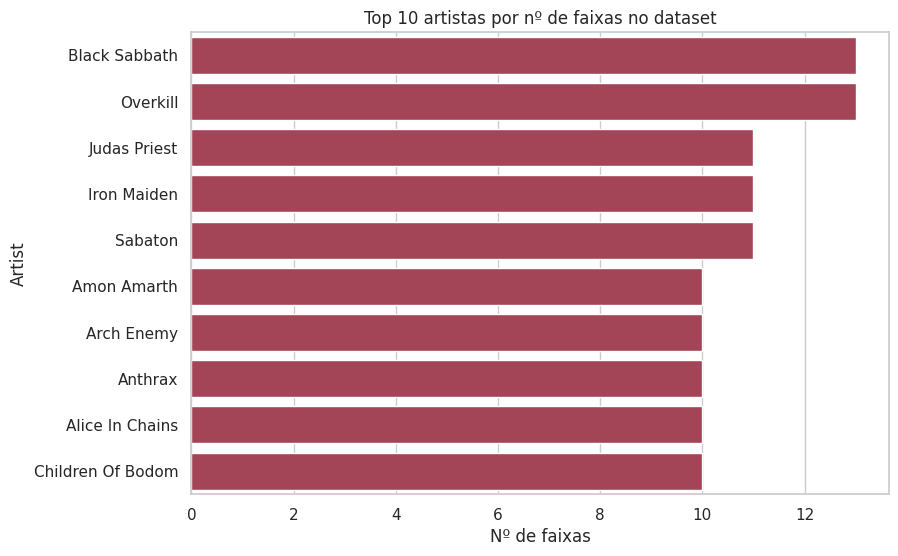

In [ ]:
top_artistas = df_clean['Artist'].value_counts().head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_artistas.values, y=top_artistas.index, color='#b3354c')
plt.title('Top 10 artistas por nº de faixas no dataset')
plt.xlabel('Nº de faixas')
plt.show()


In [ ]:
top_popularidade = df_clean.sort_values('Popularity', ascending=False)[
    ['Track', 'Artist', 'Year', 'Popularity']
].head(10).reset_index(drop=True)

top_popularidade


,Track,Artist,Year,Popularity
0,Sweet Child O' Mine,Guns N' Roses,1987,86
1,Chop Suey!,System Of A Down,2001,84
2,Toxicity,System Of A Down,2001,83
3,I Was Made For Lovin' You,Kiss,1979,82
4,Welcome To The Jungle,Guns N' Roses,1987,82
5,Paradise City,Guns N' Roses,1987,80
6,Duality,Slipknot,2004,80
7,Aerials,System Of A Down,2001,79
8,November Rain,Guns N' Roses,1991,79
9,Wind Of Change,Scorpions,1990,79


## 9. Evolução do Metal Através das Décadas

Como Energy, Loudness, Acousticness e Valence (positividade) evoluíram entre os anos 1960 e 2020?

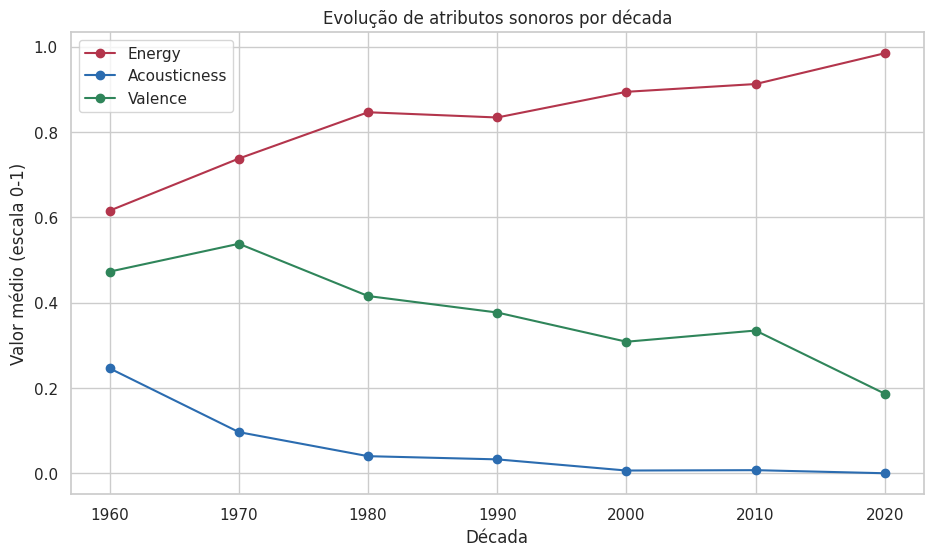

,Energy,Loudness,Acousticness,Valence,Tempo
Decade,,,,,
1960,0.616,-14.234,0.246,0.473,108.838
1970,0.738,-9.168,0.097,0.538,134.002
1980,0.847,-8.234,0.040,0.416,125.843
1990,0.834,-7.307,0.033,0.377,125.591
2000,0.895,-4.935,0.007,0.309,124.306
2010,0.913,-4.755,0.007,0.335,124.573
2020,0.985,-3.126,0.000,0.187,125.973


In [ ]:
evolucao = df_clean.groupby('Decade')[['Energy', 'Loudness', 'Acousticness', 'Valence', 'Tempo']].mean()

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(evolucao.index, evolucao['Energy'], marker='o', label='Energy', color='#b3354c')
ax1.plot(evolucao.index, evolucao['Acousticness'], marker='o', label='Acousticness', color='#2b6cb0')
ax1.plot(evolucao.index, evolucao['Valence'], marker='o', label='Valence', color='#2f855a')
ax1.set_xlabel('Década')
ax1.set_ylabel('Valor médio (escala 0-1)')
ax1.set_title('Evolução de atributos sonoros por década')
ax1.legend()
plt.show()

evolucao


**Interpretação:** observe se `Energy` se mantém alta e relativamente estável (típico de um gênero que já nasce "pesado"), enquanto `Acousticness` tende a ser baixa em quase todas as décadas. Esse tipo de gráfico ajuda a checar hipóteses como *"o metal ficou mais pesado/triste/rápido com o tempo?"* a partir dos dados, em vez de achismo.

## 10. 🔹 Diferencial 1 — Clusterização de Perfis Sonoros (K-Means)

Em vez de olhar só para artista/álbum, podemos perguntar: **existem subgrupos sonoros dentro do Classic Metal**, baseados puramente nos atributos de áudio (sem usar nome de artista)?

Usamos K-Means sobre as features de áudio padronizadas (`StandardScaler`), e usamos o método do cotovelo (elbow method) para escolher o número de clusters.

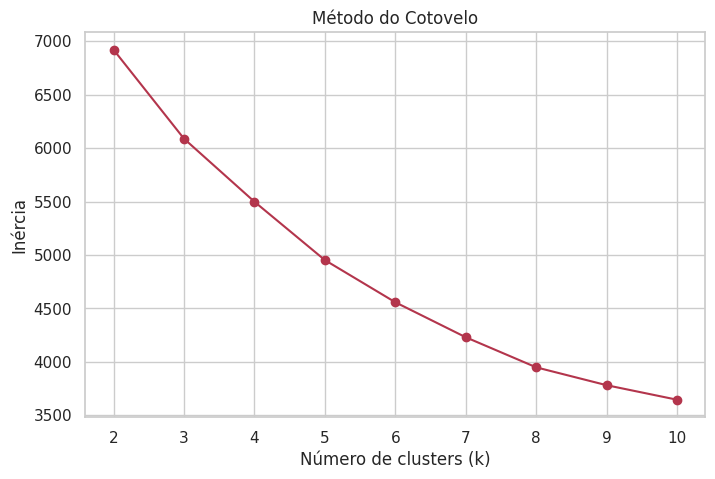

In [ ]:
features_cluster = ['Danceability', 'Energy', 'Loudness', 'Speechiness',
                     'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo']

X = df_clean[features_cluster].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', color='#b3354c')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()


In [ ]:
# Escolhido k=4 a partir do cotovelo (ajuste se o gráfico acima sugerir outro valor)
k_escolhido = 4
kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

perfil_clusters = df_clean.groupby('Cluster')[features_cluster].mean().round(3)
perfil_clusters['Qtd_faixas'] = df_clean['Cluster'].value_counts().sort_index()
perfil_clusters


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Qtd_faixas
Cluster,,,,,,,,,,
0,0.404,0.640,-10.609,0.047,0.122,0.079,0.176,0.390,121.577,167
1,0.498,0.879,-6.028,0.058,0.013,0.045,0.194,0.479,115.157,364
2,0.324,0.944,-5.436,0.125,0.007,0.061,0.272,0.268,142.262,277
3,0.349,0.885,-7.201,0.083,0.008,0.730,0.229,0.311,126.743,112


**Como interpretar:** compare as médias de cada cluster. Tipicamente aparecem perfis como:
- um cluster de **alta Energy + alta Loudness + baixa Acousticness** → "faixas pesadas/agressivas";
- um cluster de **Acousticness mais alta e Energy mais baixa** → "faixas mais melódicas/baladas dentro do metal";
- clusters intermediários com Tempo ou Valence se destacando.

Os nomes exatos dependem do resultado do seu `k` e dos dados — use a tabela acima para nomear os clusters você mesmo.

## 11. 🔹 Diferencial 2 — Visualizando os Clusters com PCA

As features de áudio têm 9 dimensões — impossível visualizar diretamente. Usamos **PCA (Análise de Componentes Principais)** para reduzir a 2 dimensões e visualizar como os clusters se separam.

Variância explicada por componente: [0.261 0.176]
Variância total explicada pelos 2 componentes: 43.7%


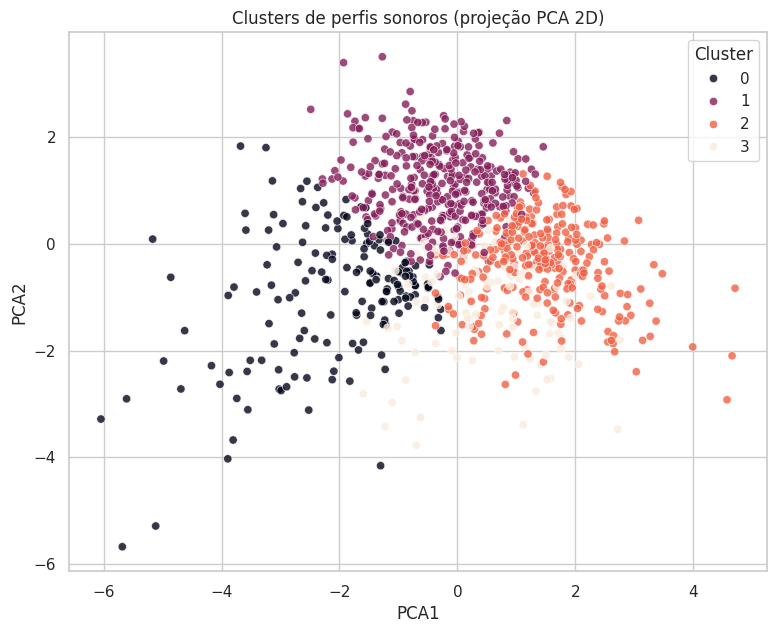

In [ ]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_scaled)

df_clean['PCA1'] = componentes[:, 0]
df_clean['PCA2'] = componentes[:, 1]

print(f"Variância explicada por componente: {pca.explained_variance_ratio_.round(3)}")
print(f"Variância total explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df_clean, x='PCA1', y='PCA2', hue='Cluster',
                 palette='rocket', alpha=0.8)
plt.title('Clusters de perfis sonoros (projeção PCA 2D)')
plt.show()


## 12. 🔹 Diferencial 3 — Teste Estatístico: a Energy mudou entre décadas?

Olhar para a média por década (seção 9) dá uma pista visual, mas não prova nada estatisticamente. Aplicamos uma **ANOVA de um fator (one-way ANOVA)** para testar formalmente se a `Energy` média difere entre as décadas.

- **H0 (hipótese nula):** a Energy média é igual em todas as décadas.
- **H1 (hipótese alternativa):** pelo menos uma década tem Energy média diferente das demais.

In [ ]:
grupos = [g['Energy'].values for _, g in df_clean.groupby('Decade')]
f_stat, p_valor = stats.f_oneway(*grupos)

print(f"Estatística F: {f_stat:.3f}")
print(f"p-valor: {p_valor:.5f}")

alpha = 0.05
if p_valor < alpha:
    print(f"\nComo p-valor < {alpha}, rejeitamos H0: há evidência estatística de que a Energy")
    print("média realmente difere entre pelo menos algumas décadas.")
else:
    print(f"\nComo p-valor >= {alpha}, não há evidência suficiente para rejeitar H0:")
    print("não podemos afirmar que a Energy média mude entre décadas.")


Estatística F: 17.742
p-valor: 0.00000

Como p-valor < 0.05, rejeitamos H0: há evidência estatística de que a Energy
média realmente difere entre pelo menos algumas décadas.


## 13. 🔹 Diferencial 4 — Modelo Preditivo de Popularidade

Vamos treinar um `RandomForestRegressor` para tentar prever a `Popularity` de uma faixa a partir de seus atributos de áudio + ano de lançamento.

⚠️ **Expectativa realista:** vimos na matriz de correlação (seção 7) que nenhuma feature de áudio tem correlação forte com `Popularity`. Popularidade no Spotify depende muito de fatores que **não estão neste dataset** (marketing, presença em playlists, redes sociais, momento cultural). Por isso, o objetivo aqui é demonstrar o pipeline de modelagem e ler as métricas com honestidade — não esperar um R² alto.

In [ ]:
features_modelo = ['Year', 'Duration_min', 'Danceability', 'Energy', 'Loudness',
                    'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness',
                    'Valence', 'Tempo', 'Mode']

X_model = df_clean[features_modelo]
y_model = df_clean['Popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R²:   {r2:.3f}")
print(f"MAE:  {mae:.2f} pontos de popularidade")
print(f"RMSE: {rmse:.2f} pontos de popularidade")


R²:   0.079
MAE:  10.69 pontos de popularidade
RMSE: 13.46 pontos de popularidade


In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, color='#b3354c')
plt.plot([0, 100], [0, 100], '--', color='gray')
plt.xlabel('Popularidade real')
plt.ylabel('Popularidade prevista')
plt.title('Real vs. Previsto — Random Forest')
plt.show()


## 14. 🔹 Diferencial 5 — Importância das Variáveis (Feature Importance)

Mesmo com um R² baixo, o modelo ainda nos diz **quais variáveis pesam mais na decisão** dele — útil para entender o que (pouco que seja) está associado a popularidade dentro deste dataset.

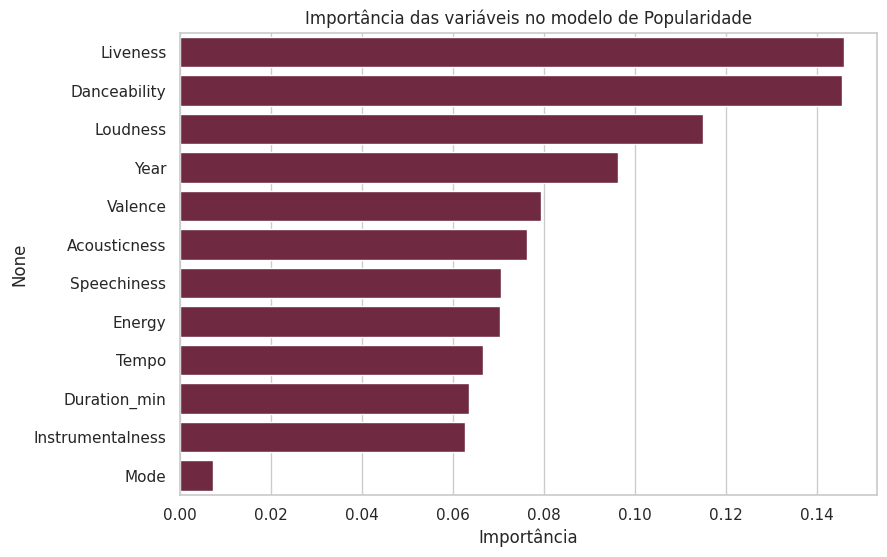

,0
Liveness,0.146
Danceability,0.146
Loudness,0.115
Year,0.096
Valence,0.079
Acousticness,0.076
Speechiness,0.071
Energy,0.070
Tempo,0.067
Duration_min,0.064


In [ ]:
importancias = pd.Series(rf.feature_importances_, index=features_modelo).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importancias.values, y=importancias.index, color='#7a1f3d')
plt.title('Importância das variáveis no modelo de Popularidade')
plt.xlabel('Importância')
plt.show()

importancias


## 15. Cruzando Clusters com Artistas

Quais artistas predominam no cluster mais "pesado" (maior Energy média) encontrado na seção 10?

Cluster mais energético: 2


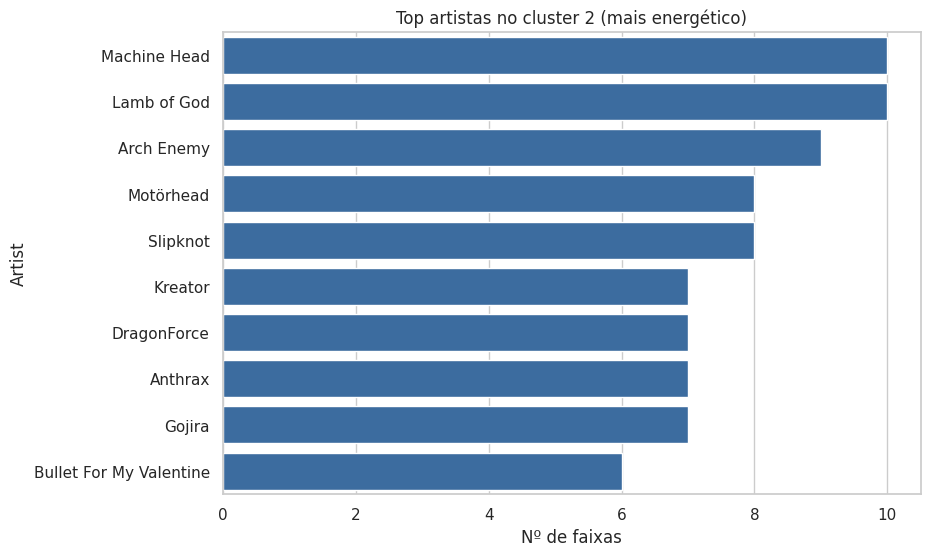

In [ ]:
cluster_mais_energetico = perfil_clusters['Energy'].idxmax()
print(f"Cluster mais energético: {cluster_mais_energetico}")

artistas_no_cluster = (
    df_clean[df_clean['Cluster'] == cluster_mais_energetico]['Artist']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(9, 6))
sns.barplot(x=artistas_no_cluster.values, y=artistas_no_cluster.index, color='#2b6cb0')
plt.title(f'Top artistas no cluster {cluster_mais_energetico} (mais energético)')
plt.xlabel('Nº de faixas')
plt.show()


## 16. Conclusões e Próximos Passos

**Principais achados:**

- O dataset cobre mais de 5 décadas (1968–2022) e 100 artistas, com qualidade de dados boa (poucos nulos/duplicados).
- `Energy` e `Loudness` são fortemente correlacionadas; `Acousticness` se comporta de forma inversa a elas.
- A `Popularity` tem correlação fraca com todas as variáveis de áudio isoladas — popularidade parece depender de fatores externos ao dataset.
- O K-Means revelou perfis sonoros distintos dentro do "Classic Metal" (faixas mais agressivas vs. mais melódicas/acústicas), visualizados com PCA.
- A ANOVA permite checar com rigor estatístico (não só visualmente) se a Energy mudou entre décadas.
- O Random Forest, mesmo limitado, confirma a fragilidade da relação áudio→popularidade e aponta quais variáveis pesam mais (mesmo que pouco).

**Possíveis próximos passos:**

- Enriquecer o dataset com dados externos (nº de streams, posição em charts, presença em playlists) para melhorar o poder preditivo do modelo de popularidade.
- Testar outros algoritmos de clusterização (DBSCAN, hierárquico) e comparar com o K-Means.
- Construir um dashboard interativo (Streamlit/Plotly Dash) a partir deste notebook.
- Expandir a análise para comparar "Classic Metal" com outros subgêneros (Thrash, Death, Power Metal etc.), se houver dados disponíveis.
